# Dari `type` Anonim Menjadi 3 Tier GrabCar

Notebook ini menjelaskan pendekatan transisi dari `type` anonim kompetisi menjadi tiga produk yang dapat dipilih pengguna: **GrabCar Hemat, Standard, dan Max**. Profil harga hanya dihitung dari train. Hasil akhirnya disimpan sebagai mapping tetap agar aplikasi tidak membutuhkan target harga dan tidak mengacak tier ketika inference.

> Catatan metodologi: clustering ini memang target-informed. Karena itu tier dipakai sebagai interpretasi produk dan kontrak deployment, bukan sebagai bukti bahwa cluster ditemukan tanpa supervisi.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
df = pd.read_csv(ROOT / 'data/train.csv')

price_by_type = (
    df.groupby('type', as_index=False)['price_mean']
      .agg(min='min', mean='mean', max='max')
      .sort_values('type')
)

display(price_by_type.head())

,type,min,mean,max
0,0,13.166667,16.760619,22.00
1,1,13.500000,16.606074,20.60
2,2,17.000000,21.087473,26.75
3,3,13.500000,20.632393,28.30
4,4,12.090909,19.168777,32.50


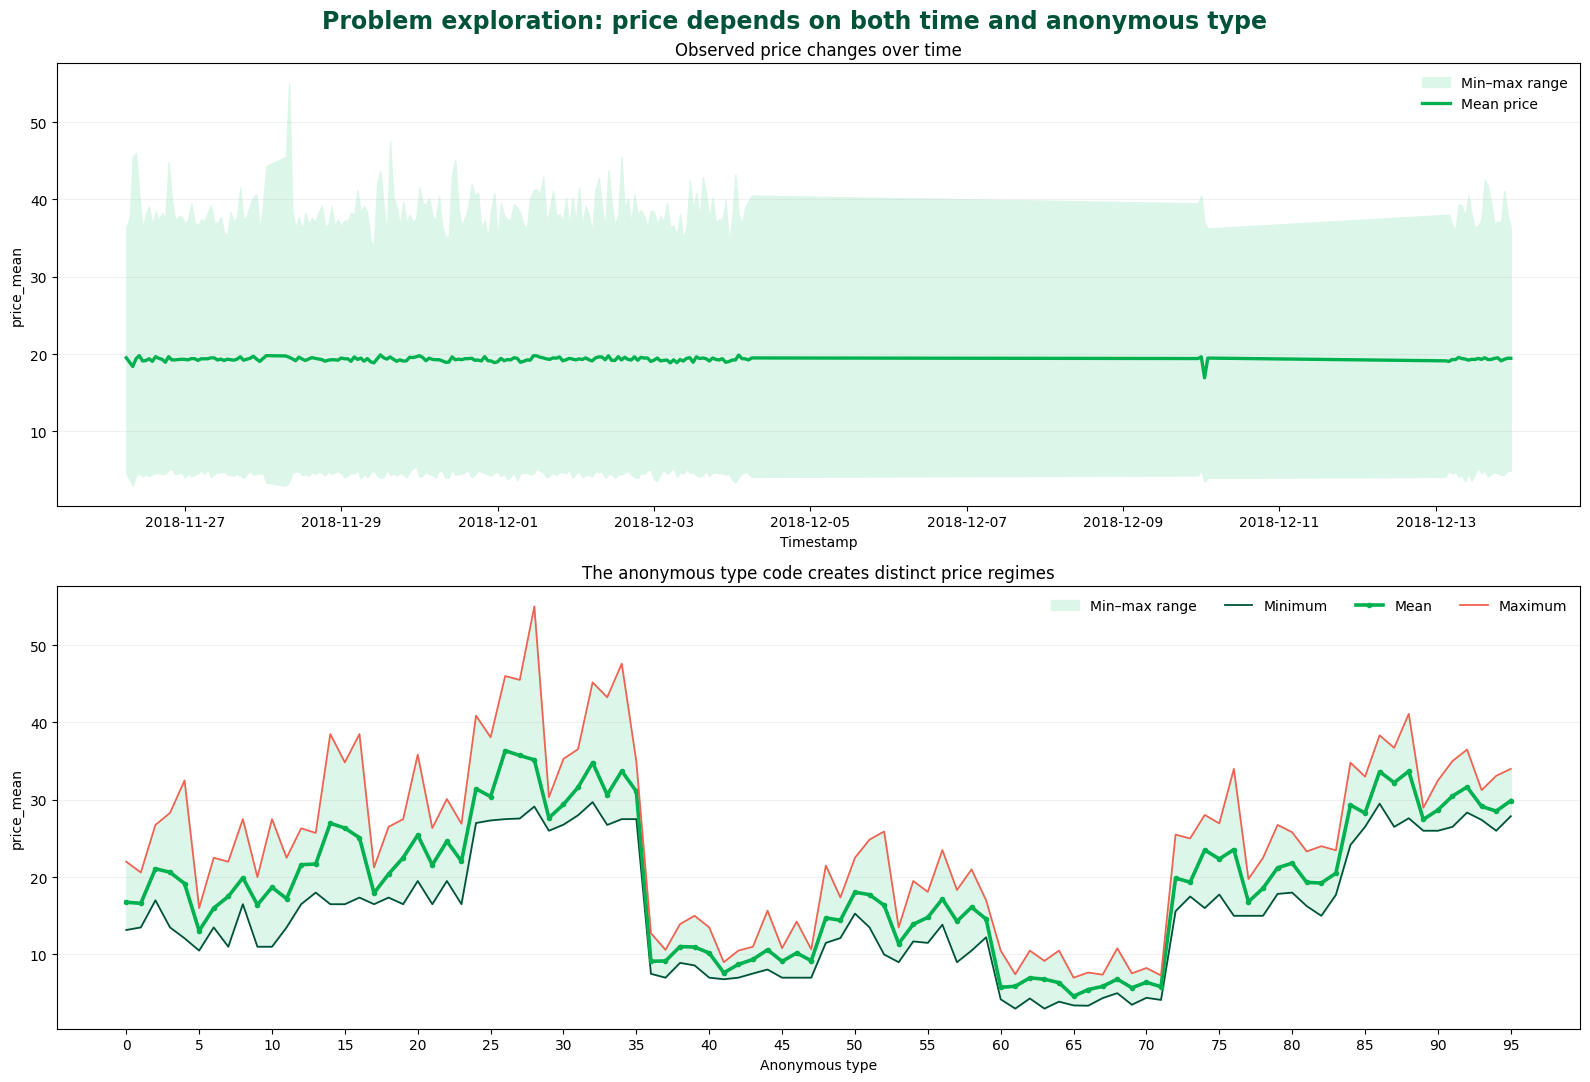

In [2]:
GRAB_GREEN = '#00B14F'
GRAB_DARK = '#005339'
GRAB_MINT = '#DDF6EA'
GRAB_CORAL = '#EE6352'

df['timestamp'] = pd.to_datetime(df['timestamp'])
price_by_time = (df.groupby('timestamp')['price_mean']
                   .agg(['min', 'mean', 'max']).reset_index())
fig, axes = plt.subplots(2, 1, figsize=(16, 11))

axes[0].fill_between(price_by_time['timestamp'], price_by_time['min'],
                     price_by_time['max'], color=GRAB_MINT, label='Min–max range')
axes[0].plot(price_by_time['timestamp'], price_by_time['mean'],
             color=GRAB_GREEN, linewidth=2.4, label='Mean price')
axes[0].set(title='Observed price changes over time', xlabel='Timestamp', ylabel='price_mean')
axes[0].legend(frameon=False); axes[0].grid(axis='y', alpha=.18)

axes[1].fill_between(price_by_type['type'], price_by_type['min'], price_by_type['max'],
                     color=GRAB_MINT, label='Min–max range')
axes[1].plot(price_by_type['type'], price_by_type['min'], color=GRAB_DARK, linewidth=1.3, label='Minimum')
axes[1].plot(price_by_type['type'], price_by_type['mean'], color=GRAB_GREEN, linewidth=2.6,
             marker='o', markersize=3, label='Mean')
axes[1].plot(price_by_type['type'], price_by_type['max'], color=GRAB_CORAL, linewidth=1.3, label='Maximum')
axes[1].set(title='The anonymous type code creates distinct price regimes',
            xlabel='Anonymous type', ylabel='price_mean')
axes[1].set_xticks(price_by_type['type'][::5])
axes[1].legend(ncol=4, frameon=False); axes[1].grid(axis='y', alpha=.18)
fig.suptitle('Problem exploration: price depends on both time and anonymous type',
             fontsize=17, fontweight='bold', color=GRAB_DARK)
plt.tight_layout()
fig.savefig(ROOT / 'docs/images/problem-price-patterns.png', dpi=160, bbox_inches='tight')
plt.show()

## Membuat fitur cluster untuk `type`

Constraint bisnis mewajibkan tepat **3 cluster** dan eksperimen dibatasi pada **3 fitur distribusi**. Kombinasi `minimum`, `P10`, dan `P25` memisahkan batas harga dasar tiap `type` paling jelas pada silhouette score. Agglomerative clustering dengan Ward linkage dipakai karena jumlah `type` kecil dan kita ingin segmentasi bertingkat, bukan centroid yang harus dipakai untuk menebak request baru. Ketiga statistik dihitung hanya dari train lalu distandardisasi.

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Profil target per type, dibuat dari TRAIN saja.
type_profile = (
    df.groupby('type', as_index=False)['price_mean']
      .agg(price_mean_min='min',
           price_mean_p10=lambda s: s.quantile(.10),
           price_mean_p25=lambda s: s.quantile(.25))
)
cluster_features = [
    'price_mean_min', 'price_mean_p10', 'price_mean_p25'
]

scaler = StandardScaler()
X_type = scaler.fit_transform(type_profile[cluster_features])

N_CLUSTERS = 3
cluster_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
type_profile['type_cluster_raw'] = cluster_model.fit_predict(X_type)
silhouette = silhouette_score(X_type, type_profile['type_cluster_raw'])

# Nomor cluster diurutkan dari cluster termurah ke termahal agar mudah dibaca.
cluster_order = (type_profile.groupby('type_cluster_raw')['price_mean_p25']
                 .mean().sort_values().index)
cluster_remap = {old: new for new, old in enumerate(cluster_order)}
type_profile['type_cluster'] = type_profile['type_cluster_raw'].map(cluster_remap)

print(f'Jumlah cluster: {N_CLUSTERS}')
print(f'Silhouette score: {silhouette:.6f}')
display(type_profile.sort_values(['type_cluster', 'price_mean_p25']))

Jumlah cluster: 3
Silhouette score: 0.660389


,type,price_mean_min,price_mean_p10,price_mean_p25,type_cluster_raw,type_cluster
65,65,3.416667,4.038462,4.333333,2,0
66,66,3.375000,4.837500,5.090241,2,0
69,69,3.500000,5.000000,5.327586,2,0
60,60,4.200000,5.017849,5.357143,2,0
67,67,4.366667,5.200833,5.500000,2,0
...,...,...,...,...,...,...
86,86,29.500000,32.000000,32.572917,1,2
28,28,29.125000,31.525000,33.126374,1,2
32,32,29.700000,32.333333,33.200000,1,2
27,27,27.583333,32.866667,33.849026,1,2


In [4]:
# Mapping migrasi dari type anonim kompetisi ke kontrak fitur production.
type_cluster_mapping = type_profile[['type']].copy()
type_cluster_mapping['service_tier_id'] = type_profile['type_cluster'] + 1
tier_names = {
    1: 'GrabCar Hemat',
    2: 'GrabCar Standard',
    3: 'GrabCar Max',
}
type_cluster_mapping['service_tier'] = (
    type_cluster_mapping['service_tier_id'].map(tier_names)
)
train_featured = df.merge(type_cluster_mapping, on='type', how='left', validate='many_to_one')
test = pd.read_csv(ROOT / 'data/test.csv')
test_featured = test.merge(type_cluster_mapping, on='type', how='left', validate='many_to_one')

# Type baru yang tidak pernah ada di train mendapat cluster -1.
train_featured['service_tier_id'] = train_featured['service_tier_id'].fillna(0).astype(int)
test_featured['service_tier_id'] = test_featured['service_tier_id'].fillna(0).astype(int)

type_cluster_mapping.to_csv(ROOT / 'artifacts/type_cluster_mapping.csv', index=False)
print('Mapping tersimpan: artifacts/type_cluster_mapping.csv')
print('Missing tier di train:', (train_featured['service_tier_id'] == 0).sum())
print('Missing tier di test :', (test_featured['service_tier_id'] == 0).sum())
display(type_cluster_mapping.sort_values(['service_tier_id', 'type']))

Mapping tersimpan: artifacts/type_cluster_mapping.csv
Missing tier di train: 0
Missing tier di test : 0


,type,service_tier_id,service_tier
36,36,1,GrabCar Hemat
37,37,1,GrabCar Hemat
38,38,1,GrabCar Hemat
39,39,1,GrabCar Hemat
40,40,1,GrabCar Hemat
...,...,...,...
91,91,3,GrabCar Max
92,92,3,GrabCar Max
93,93,3,GrabCar Max
94,94,3,GrabCar Max


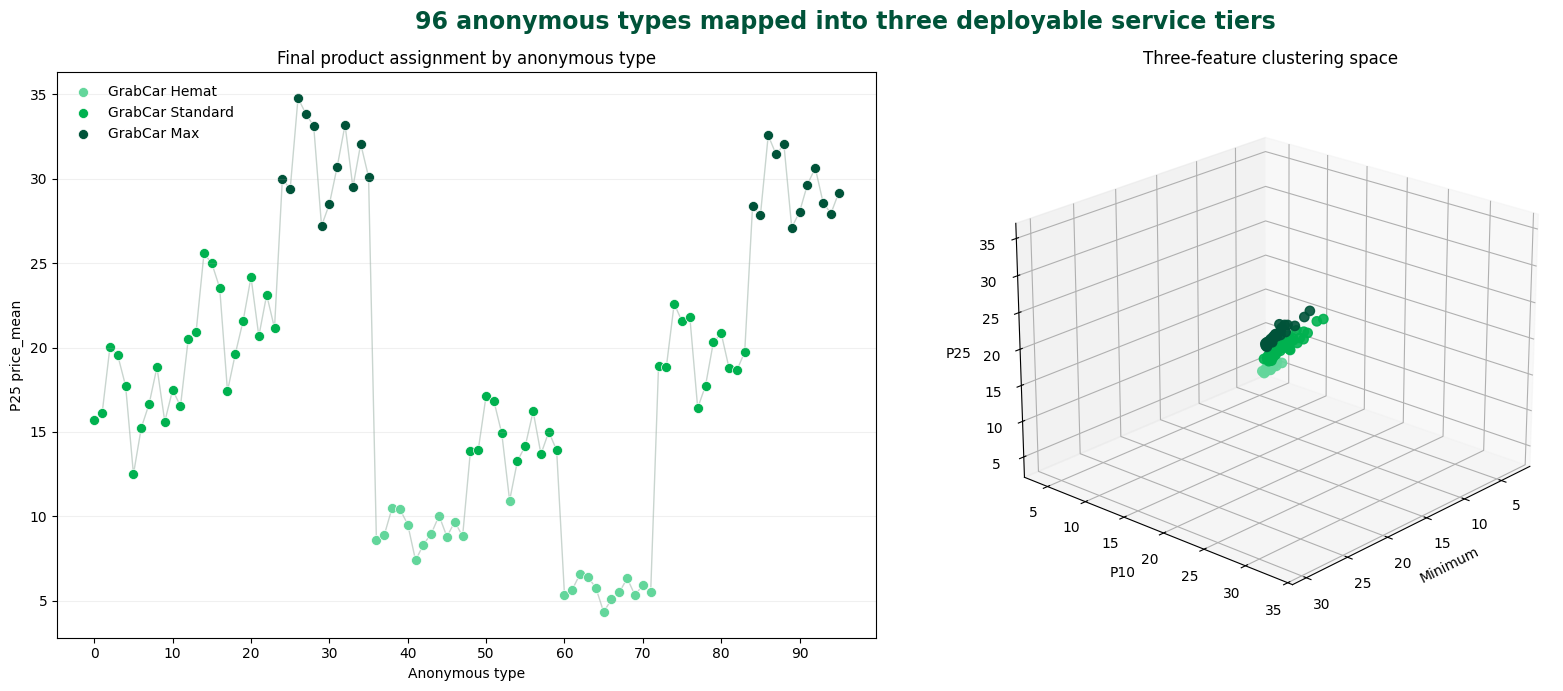

In [5]:
tier_palette = {1: '#63D69B', 2: '#00B14F', 3: '#005339'}
type_profile['service_tier_id'] = type_profile['type_cluster'] + 1
type_profile['service_tier'] = type_profile['service_tier_id'].map(tier_names)

fig = plt.figure(figsize=(17, 7))
ax = fig.add_subplot(1, 2, 1)
for tier_id, part in type_profile.sort_values('type').groupby('service_tier_id'):
    ax.scatter(part['type'], part['price_mean_p25'], s=52, color=tier_palette[tier_id],
               label=tier_names[tier_id], edgecolor='white', linewidth=.5)
ax.plot(type_profile['type'], type_profile['price_mean_p25'], color='#C9D5CF', linewidth=1, zorder=0)
ax.set(title='Final product assignment by anonymous type', xlabel='Anonymous type', ylabel='P25 price_mean')
ax.set_xticks(type_profile['type'][::10]); ax.grid(axis='y', alpha=.18); ax.legend(frameon=False)

ax3d = fig.add_subplot(1, 2, 2, projection='3d')
for tier_id, part in type_profile.groupby('service_tier_id'):
    ax3d.scatter(part['price_mean_min'], part['price_mean_p10'], part['price_mean_p25'],
                 s=45, color=tier_palette[tier_id], label=tier_names[tier_id], alpha=.9)
ax3d.set(xlabel='Minimum', ylabel='P10', zlabel='P25', title='Three-feature clustering space')
ax3d.view_init(elev=22, azim=42)
fig.suptitle('96 anonymous types mapped into three deployable service tiers',
             fontsize=17, fontweight='bold', color=GRAB_DARK)
plt.tight_layout()
fig.savefig(ROOT / 'docs/images/type-tier-clustering.png', dpi=160, bbox_inches='tight')
plt.show()